# Phase 4 & 5: Ensemble and Evaluation

This notebook analyses the performance of the HMM-LSTM ensemble model against the monolithic baseline LSTM.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import DATA_PROCESSED
from src.utils import regression_metrics, print_metrics, _apply_style

## 1. Load Ensemble Predictions
Load the pre-computed test set predictions from all models.

In [2]:
df_eval = pd.read_parquet(DATA_PROCESSED / "test_predictions.parquet")
df_eval

,baseline,calm,volatile,target,p_calm,p_volatile,ensemble
Date,,,,,,,
2020-06-30,0.016753,0.015973,0.030941,0.008124,1.0,3.631634e-14,0.015973
2020-07-01,0.015917,0.015020,0.030871,0.008150,1.0,3.467398e-16,0.015020
2020-07-02,0.016061,0.015030,0.030810,0.008182,1.0,6.654507e-16,0.015030
2020-07-06,0.015668,0.014608,0.030691,0.007673,1.0,9.294703e-13,0.014608
2020-07-07,0.016567,0.015371,0.030635,0.007207,1.0,2.761108e-15,0.015371
...,...,...,...,...,...,...,...
2026-03-10,0.096442,0.080768,0.020037,0.012221,1.0,1.788263e-20,0.080768
2026-03-11,0.095582,0.080026,0.020037,0.012218,1.0,2.308510e-21,0.080026
2026-03-12,0.095058,0.079503,0.020036,0.011848,1.0,7.735482e-19,0.079503


## 2. Naive Baseline
A simple, strong baseline for 21-day forward volatility is simply the *historical* 21-day volatility at the prediction date.

In [3]:
# Load the raw features to get the historical vol
test_df = pd.read_parquet(DATA_PROCESSED / "test.parquet")
df_eval['naive'] = test_df['rolling_std_21'].reindex(df_eval.index)
df_eval = df_eval.dropna()

## 3. Overall Performance Metrics

In [4]:
models = ["naive", "baseline", "calm", "volatile", "ensemble"]
results = []
for m in models:
    metrics = regression_metrics(df_eval["target"].values, df_eval[m].values)
    metrics["Model"] = m.capitalize()
    results.append(metrics)

perf_df = pd.DataFrame(results).set_index("Model")
perf_df

,MSE,RMSE,MAE,MAPE
Model,,,,
Naive,0.000022,0.004695,0.003133,34.617512
Baseline,0.002466,0.049656,0.045776,598.207852
Calm,0.001724,0.041523,0.037431,494.010524
Volatile,0.000145,0.012059,0.011379,155.236003
Ensemble,0.001672,0.040893,0.036617,487.153070


## 4. Visualisation

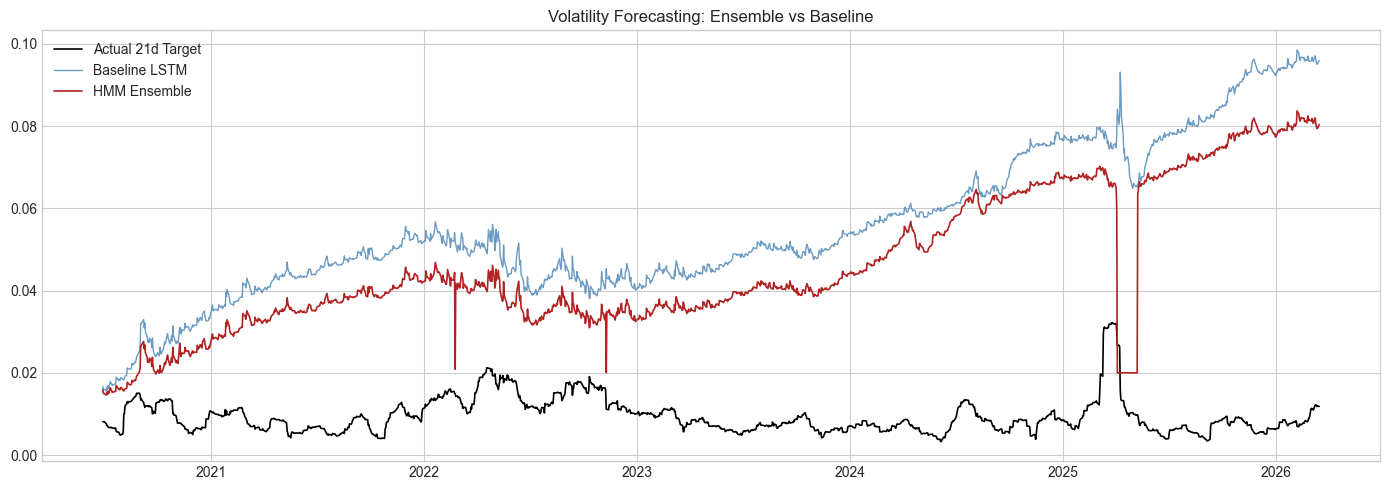

In [5]:
_apply_style()
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_eval.index, df_eval["target"], color="black", label="Actual 21d Target", linewidth=1.2)
ax.plot(df_eval.index, df_eval["baseline"], color="steelblue", label="Baseline LSTM", linewidth=1.0, alpha=0.8)
ax.plot(df_eval.index, df_eval["ensemble"], color="firebrick", label="HMM Ensemble", linewidth=1.2)

ax.set_title("Volatility Forecasting: Ensemble vs Baseline")
ax.legend()
plt.tight_layout()
plt.show()

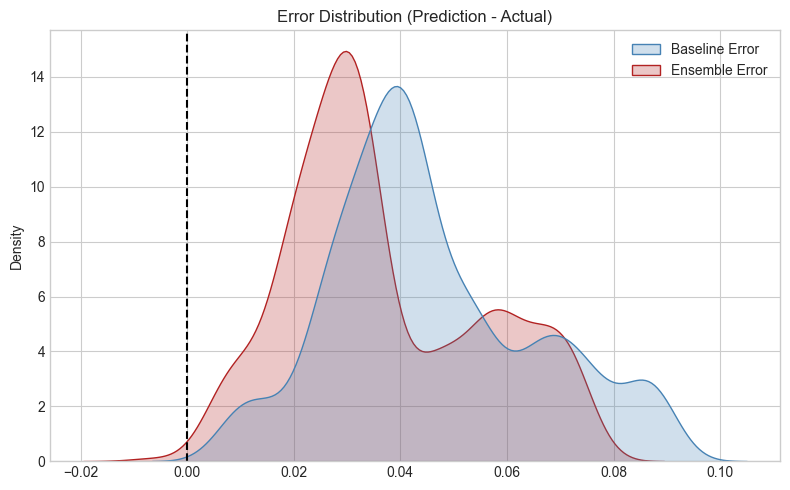

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
errors = pd.DataFrame({
    "Baseline Error": df_eval["baseline"] - df_eval["target"],
    "Ensemble Error": df_eval["ensemble"] - df_eval["target"],
})

sns.kdeplot(data=errors, fill=True, ax=ax, palette=["steelblue", "firebrick"])
ax.axvline(0, color="black", linestyle="--")
ax.set_title("Error Distribution (Prediction - Actual)")
plt.tight_layout()
plt.show()

## 5. Performance by Dominant Regime
Let's see where the ensemble makes its gains by isolating days where the HMM is highly confident.

In [7]:
calm_mask = df_eval["p_calm"] > 0.8
vol_mask = df_eval["p_volatile"] > 0.8

for mask, label in [(calm_mask, "Strictly Calm"), (vol_mask, "Strictly Volatile")]:
    print(f"\n--- {label} Periods (n={mask.sum()}) ---")
    sub = df_eval[mask]
    for m in ["baseline", "ensemble"]:
        mse = np.mean((sub[m] - sub["target"])**2)
        rmse = np.sqrt(mse)
        print(f"{m.capitalize()}: MSE={mse:.5f}, RMSE={rmse:.4f}")


--- Strictly Calm Periods (n=1407) ---
Baseline: MSE=0.00245, RMSE=0.0495
Ensemble: MSE=0.00170, RMSE=0.0413

--- Strictly Volatile Periods (n=27) ---
Baseline: MSE=0.00335, RMSE=0.0579
Ensemble: MSE=0.00009, RMSE=0.0094
